In [44]:
import pykasso as pk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import plotly.graph_objects as go
import networkx
import importlib
import seaborn as sns
import os
import sys
import gempy as gp
import gempy_viewer as gpv
import contextily as cx
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../src"))) #use this to be able to import local packages
from matplotlib_scalebar.scalebar import ScaleBar
import random
# import cfpy

In [40]:
import utils.common
import utils.conduits
import utils.openkarst_network
import utils.geos
importlib.reload(utils.openkarst_network)
importlib.reload(utils.common)
importlib.reload(utils.geos)
importlib.reload(utils.conduits)
from utils.common import *
from utils.geos import * 
from utils.conduits import *
import utils.openkarst_network as okn


In [41]:
import bear_spring_pykasso_settings
importlib.reload(bear_spring_pykasso_settings)
from bear_spring_pykasso_settings import *

# Generate Single Straight Line Conduit

In [20]:
nodes = pd.read_csv('../../data/networks/single_conduit/straight_conduit_n62/nodes.csv')
edges = pd.read_csv('../../data/networks/single_conduit/straight_conduit_n62/edges.csv')

In [21]:
plot_3D_network(nodes, edges, node_color='type')

In [24]:
edges['length'] = np.sqrt((edges.x_0 - edges.x_1)**2 + (edges.y_0 - edges.y_1)**2 + (edges.z_0 - edges.z_1)**2)

# Generate Straight Line Multi-conduit Network

In [51]:
new_nodes = pd.read_csv('../../data/networks/multiconduit/straight_n5/nodes.csv', index_col=False)
new_edges = pd.read_csv('../../data/networks/multiconduit/straight_n5/edges.csv', index_col=False)
new_edges = extract_edge_coordinates(new_nodes, new_edges)
new_nodes, new_edges = densify_edges(new_nodes, new_edges, density_factor=20)
new_nodes, new_edges = reset_node_ids(new_nodes, new_edges)

In [37]:
new_edges['length'] =  np.sqrt((new_edges.x_0 - new_edges.x_1)**2 + (new_edges.y_0 - new_edges.y_1)**2 + (new_edges.z_0 - new_edges.z_1)**2)

In [55]:
new_nodes.to_csv('../steady_state/conduit_geometry_test/networks/branching_straight_network/nodes.csv', index = False)
new_edges.to_csv('../steady_state/conduit_geometry_test/networks/branching_straight_network/edges.csv', index = False)

In [53]:
plot_3D_network(new_nodes, new_edges, node_color='type')

# Generate Geologic Model

In [104]:
cost = np.random.rand(588,475,2)
nx = grid_parameters['nx']
ny = grid_parameters['ny']
nz = grid_parameters['nz']
geo = np.random.randint(0, 2, size = (nx, ny, nz))
geology_costs = {0 : 0.01,
                 1 : .8}
geology_model = { 0 : True, 1 : True}


# Generate Network with PyKasso

In [38]:
import bear_spring_pykasso_settings
importlib.reload(bear_spring_pykasso_settings)
from bear_spring_pykasso_settings import *

In [105]:
app = pk.pykasso()
# Create a new project and declare its parameters
app.new_project(name=name, grid_parameters=grid_parameters)
app.visualizer.notebook = True
nx, ny, nz = app.project.grid.shape

In [106]:
settings = 'dye_trace'

In [72]:
DEM_path = '../../data/DEM/dem_1m_m.bil'
crs = 'EPSG:32615'
grid = read_DEM_data(DEM_path, x0, x1, y0, y1, dx, dy, crs)

In [107]:
azimuth = 350
dip = 0 #np.pi/180/5
slope = np.tan(dip)
azimuth_rad = np.radians(azimuth)
dz_dx = slope * np.cos(azimuth_rad)  # Change in Z per unit X
dz_dy = slope * np.sin(azimuth_rad)  # Change in Z per unit Y
x, y = np.meshgrid(np.arange(nx), np.arange(ny))
grid = z1 - ((nx - x-1)* dx * dz_dx) + ((ny - y-1) * dy * dz_dy)

In [75]:
bedrock = grid - 10#assume bedrock is right below surface

In [ ]:
app.model.grid.is_inbox( [558522.0, 4867747.0] )
app.model._is_point_valid( , 'inlets' )

array([False])

In [108]:
i, j = app.model.grid.get_indices([558522.0, 4867747.0])
app.model._points['inlets']['data'].max(axis=2)[i, j] > 0

AttributeError: 'SKS' object has no attribute '_points'

In [103]:
app.model._points['inlets']['data'].max(axis=2)[i,j]

array([0])

In [111]:
# top = np.load('../../data/DEM/dem_grid_bear_spring.npy')
model_parameters[settings]['domain']['topography'] = grid.T
model_parameters[settings]['geology'] = {
        'data' : geo,
        'costs' : geology_costs,
        'model' : geology_model
    }
# model_parameters[settings]['domain']['bedrock'] = bedrock.T

In [112]:
for i in range(1):
    app.model.generate(model_parameters[settings])
    # print(app.model.model_parameters['sks']['seed'])


ValueError: Point with coordinates [558522.0, 4867747.0] is invalid in subdomain 'domain_surface'.

In [79]:
edges = pd.DataFrame.from_dict(app.model.vectors['edges'], orient = 'index')
nodes = pd.DataFrame.from_dict(app.model.vectors['nodes'], orient ='index')
nodes.columns = ['x', 'y', 'z', 'type']
nodes = nodes.reset_index().rename({'index':'id'}, axis=1)
# nodes['z'] = 395 # set all nodes to the same elevation to create a 2D network
edges.columns = ['from_id', 'to_id']
edges = extract_edge_coordinates(nodes, edges)

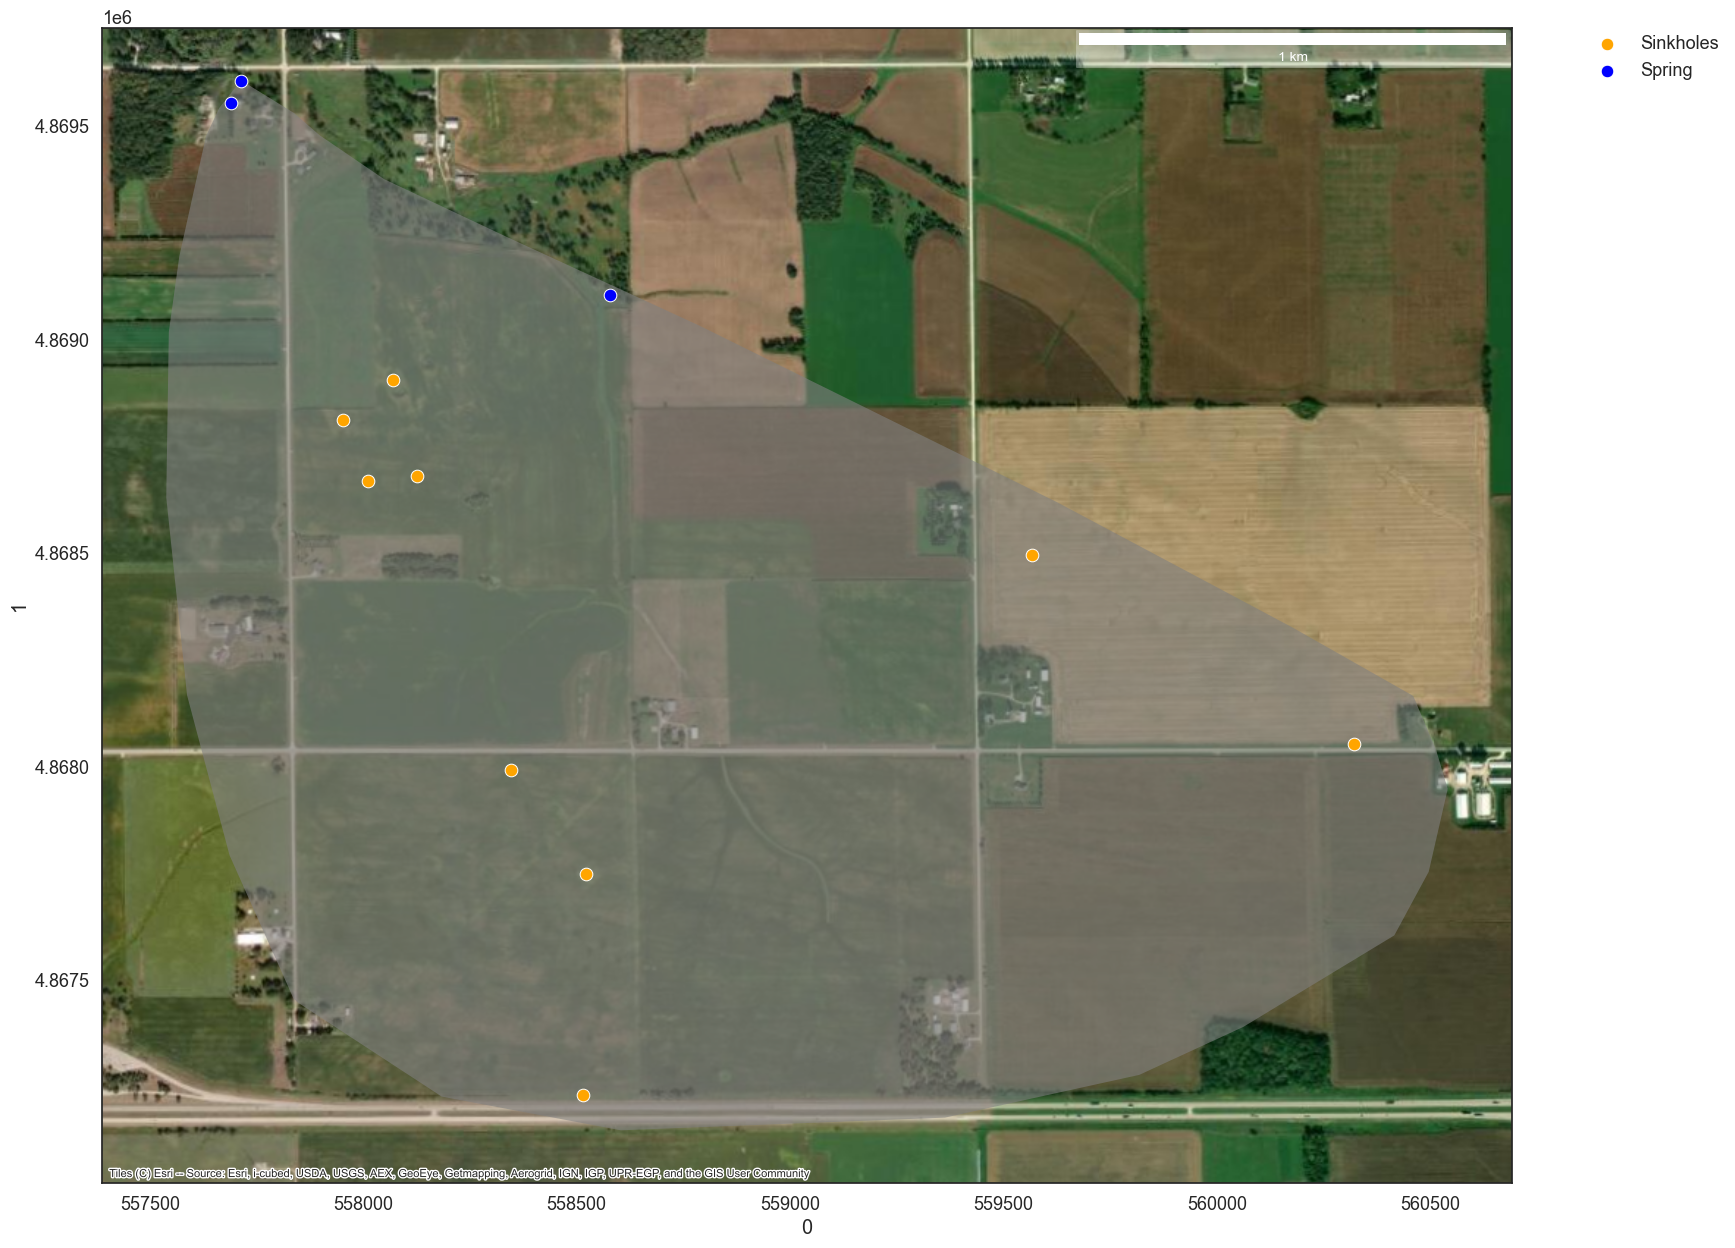

In [46]:
fig, ax = plt.subplots(figsize = (20,15))
springshed = load_geojson('../../data/geo_data/Bear_Springshed.geojson')
sinkholes = pd.read_csv('../../data/geo_data/sinkholes/sinkholes_dye_trace_2d.csv', header = None)
spring = pd.read_csv('../../data/geo_data/springs/springs_coords.txt', delimiter = ' ', header = None)

springshed.plot(ax= ax, alpha = 0.6, color = 'grey')
sns.scatterplot(sinkholes, x = 0, y = 1, color = 'orange', label = 'Sinkholes')
sns.scatterplot(spring, x = 0, y = 1, color = 'blue', label = 'Spring')
source = cx.providers.Esri.WorldImagery
scalebar= ScaleBar(1, fixed_units = 'km', fixed_value = 1, box_alpha = 0.3, color = 'white')
ax.add_artist(scalebar)
# sns.scatterplot(ax = ax, data = nodes[nodes.type == 'outfall'], x= 'x', y ='y', color = 'blue', label = 'spring')
cx.add_basemap(
    ax, 
    crs='EPSG:32615', 
    source=source, 
    zoom="auto"
)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.savefig('dye_trace_map.png', transparent = True, bbox_inches='tight')


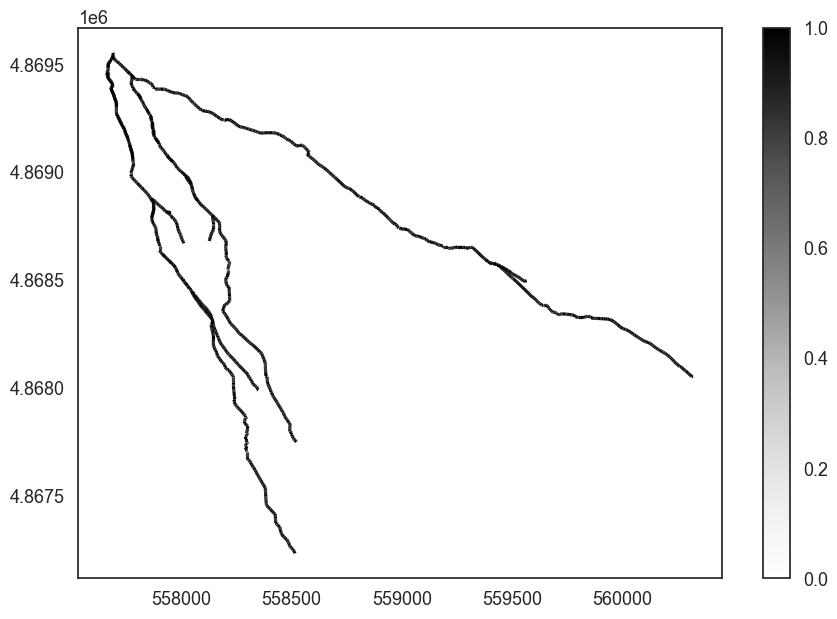

In [80]:
ax = plot_2D_network(nodes, edges, grid = False)
# plt.savefig('test_fig', transparent = True)


c:\Users\huan1428\.conda\envs\pyKasso\Lib\site-packages\matplotlib_scalebar\scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(


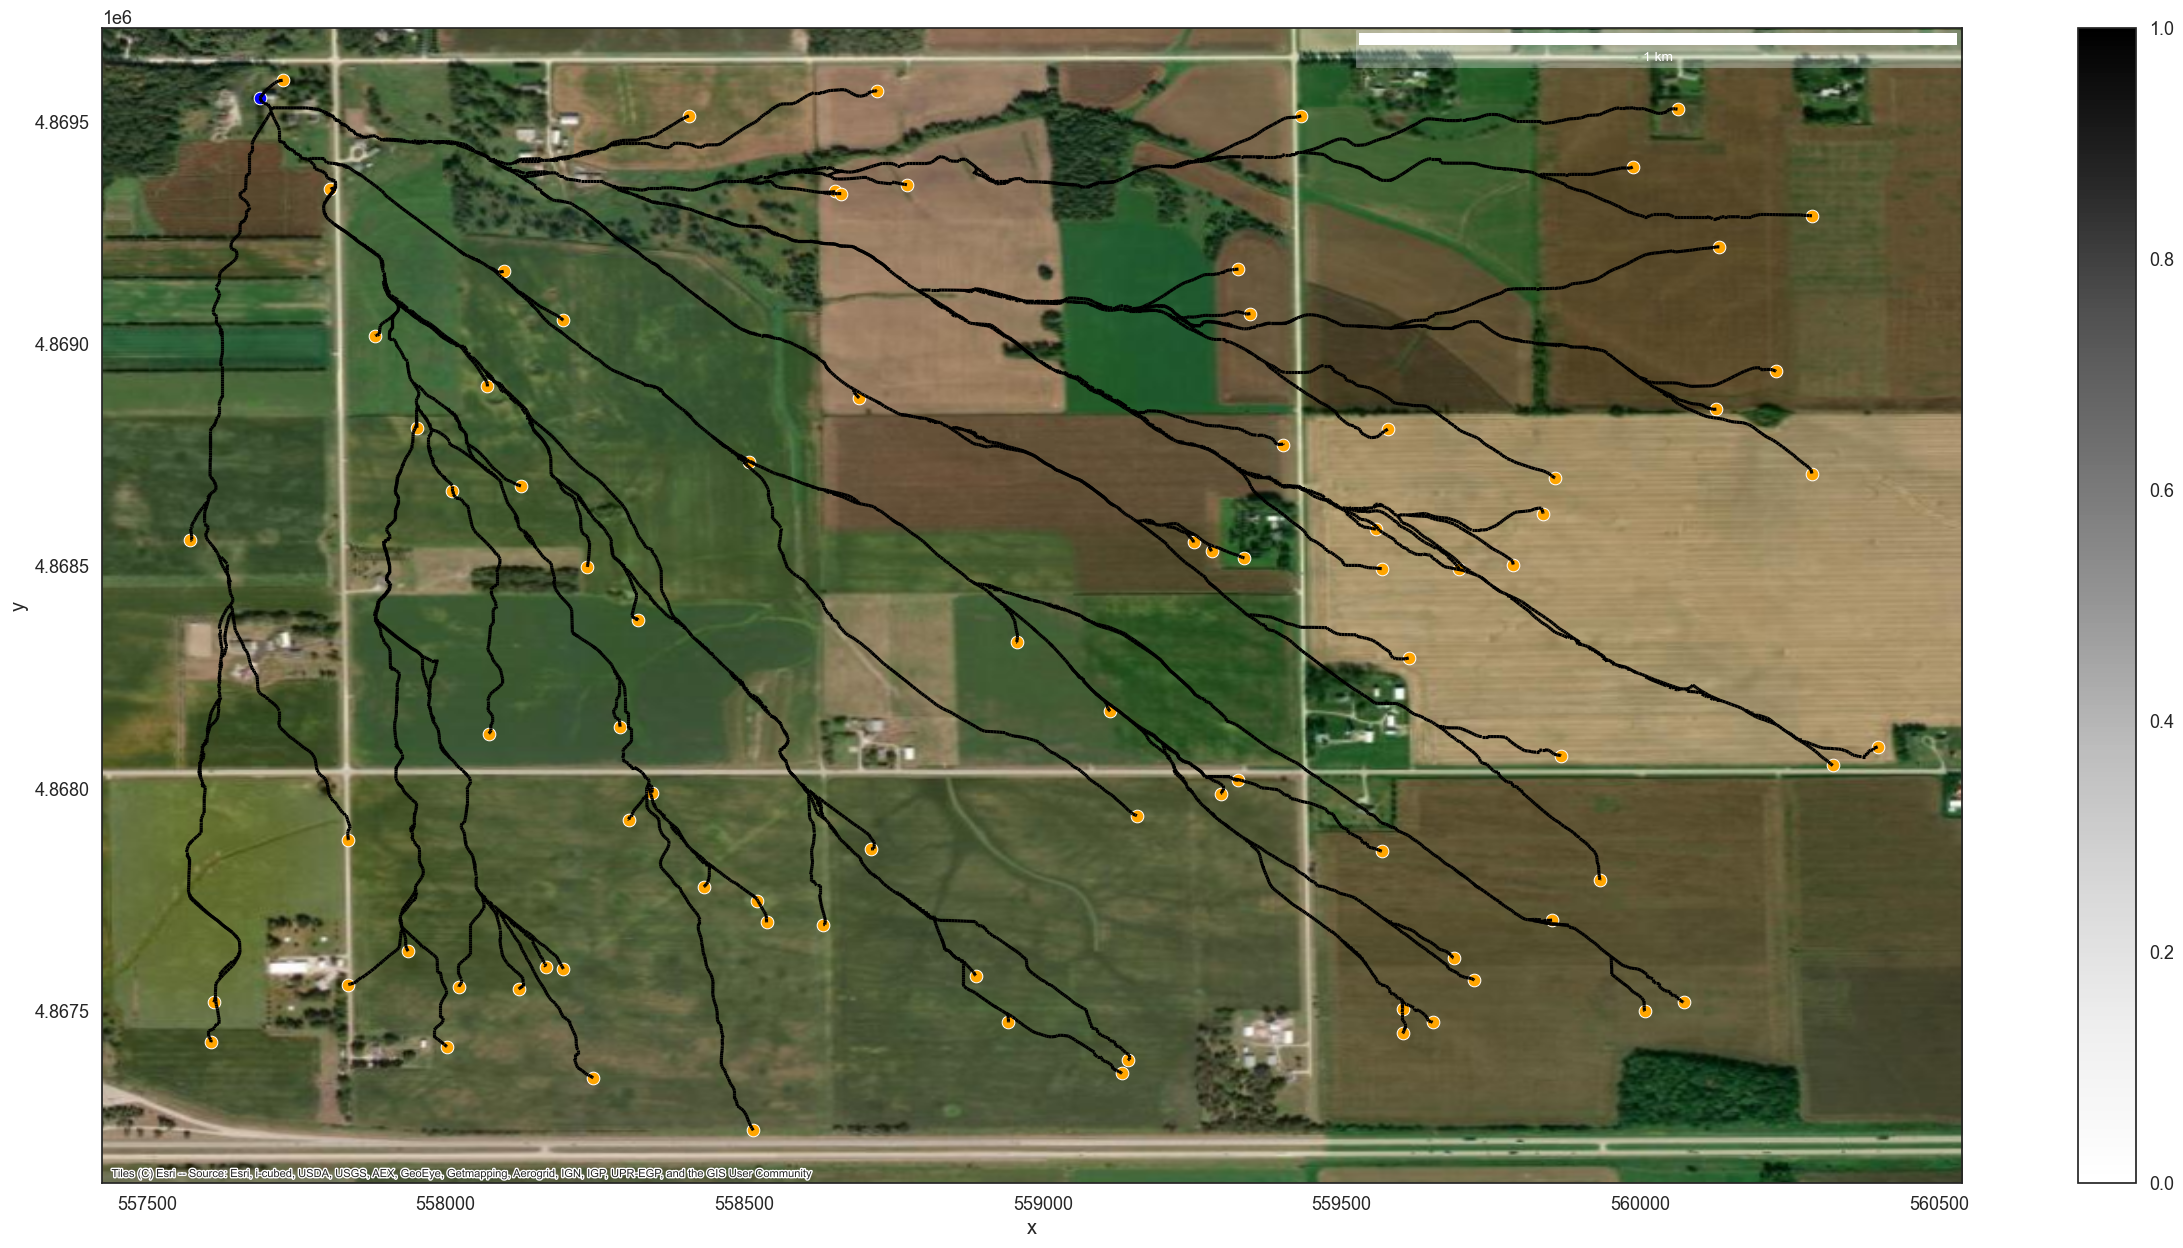

In [ ]:
fig, ax = plt.subplots(figsize = (30,15))
plot_2D_network(nodes, edges, grid = False, ax =ax )
# springshed.plot(ax= ax, alpha = 0.6, color = 'grey')
sns.scatterplot(nodes[(nodes.type == 'outlet')], x = 'x', y = 'y', color = 'blue')
sns.scatterplot(nodes[(nodes.type == 'inlet')], x = 'x', y = 'y', color = 'orange')

source = cx.providers.Esri.WorldImagery
scalebar= ScaleBar(1, fixed_units = 'km', fixed_value = 1, box_alpha = 0.3, color = 'white')
ax.add_artist(scalebar)
# sns.scatterplot(ax = ax, data = nodes[nodes.type == 'outfall'], x= 'x', y ='y', color = 'blue', label = 'spring')
cx.add_basemap(
    ax, 
    crs='EPSG:32615', 
    source=source, 
    zoom="auto"
)
# plt.savefig('test_fig', transparent = True)

In [ ]:
plot_3D_network(nodes, edges, node_color='type')

In [15]:
coords = get_cell_id_from_coords(nodes[nodes.type == 'inlet'].x, nodes[nodes.type=='inlet'].y, x0, y1, dy, dx)

In [153]:
coords = app.project.grid.get_indices(nodes[nodes.type == 'inlet'][['x', 'y']])

<Axes: xlabel='x', ylabel='y'>

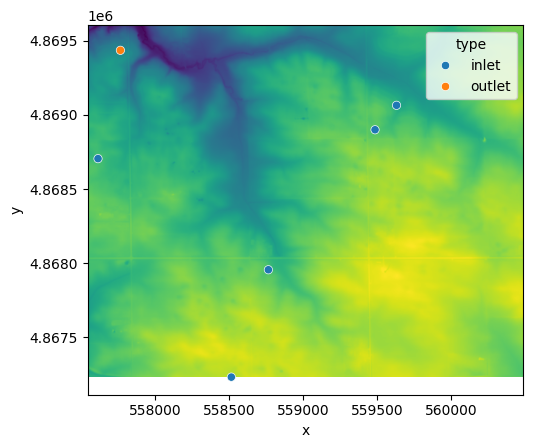

In [150]:
plt.imshow(grid, extent = (x0, x1, y0, y1))
sns.scatterplot(nodes[(nodes.type =='inlet') |(nodes.type =='outlet') ], x = 'x', y = 'y', hue = 'type')

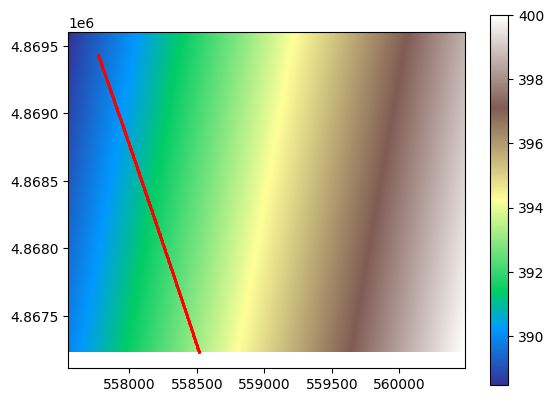

In [113]:
plt.imshow(grid, extent=(x0, x1, y0, y1), origin='upper', cmap='terrain')
plt.colorbar()
plt.scatter(nodes['x'], nodes['y'], c='r', s=1)

In [186]:
plot_3D_network(nodes, edges, node_color='type')

## Changing Slope

In [191]:
dz = 2
nodes = pd.read_csv("../steady_state/conduit_geometry_test/networks/sinkhole_spring/nodes.csv")
nodes.loc[nodes.type == 'inlet', 'z'] = dz
nodes.loc[nodes.type=='outlet', 'z'] = 0

In [192]:
edges = pd.DataFrame({'from_id' : [0], 'to_id' : [1]})
nodes, edges = reset_node_ids(nodes, edges)
nodes, edges = densify_edges(nodes, edges, 70)
edges = conduit_lengths(nodes, edges)
edges['dz_dl'] = (edges.z_1 - edges.z_0)/edges.length
plot_3D_network(nodes, edges, node_color = 'type', edge_color = 'dz_dl')

In [195]:
nodes.to_csv("../steady_state/conduit_geometry_test/networks/slope_0008/nodes.csv", index = False)
edges.to_csv("../steady_state/conduit_geometry_test/networks/slope_0008/edges.csv", index = False )

# Calculate Metrics

In [37]:
# nodes = pd.read_csv("../steady_state/conduit_geometry_test/networks/branching_straight_network/nodes.csv")
# edges = pd.read_csv("../steady_state/conduit_geometry_test/networks/branching_straight_network/edges.csv")
simple_nodes, simple_edges = reduce_node_density(nodes, edges, 10)
simple_nodes, simple_edges = reset_node_ids(simple_nodes, simple_edges)
network = okn.OpenKarstNetwork(nodes=simple_nodes, edges = simple_edges)
network.load_cave_data()

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [38]:
simple_edges

,from_id,to_id,x_0,y_0,z_0,x_1,y_1,z_1
0,0.0,NaN,558515.000000,4.867230e+06,395,558512.541859,4.867233e+06,395
1,NaN,NaN,558512.541859,4.867233e+06,395,558510.046918,4.867235e+06,395
2,NaN,NaN,558510.046918,4.867235e+06,395,558507.029685,4.867238e+06,395
3,NaN,NaN,558507.029685,4.867238e+06,395,558504.787179,4.867240e+06,395
4,NaN,NaN,558504.787179,4.867240e+06,395,558503.464353,4.867241e+06,395
...,...,...,...,...,...,...,...,...
12137,545.0,NaN,557686.887069,4.869205e+06,395,557685.956160,4.869211e+06,395
12138,NaN,NaN,557685.956160,4.869211e+06,395,557685.965512,4.869217e+06,395
12139,NaN,547.0,557685.965512,4.869217e+06,395,557684.362833,4.869225e+06,395
12140,1347.0,NaN,557682.270896,4.869294e+06,395,557683.746337,4.869297e+06,395


<Axes: >

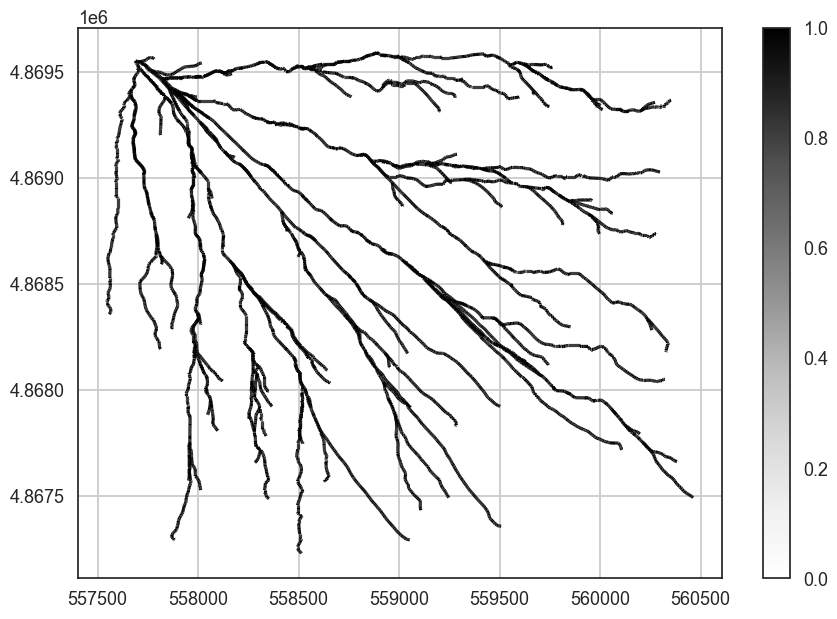

In [36]:
plot_2D_network(simple_nodes, simple_edges)

In [28]:
degree = pd.DataFrame(network.graph.degree(), columns = ['id', 'degree'])

<Axes: xlabel='x', ylabel='y'>

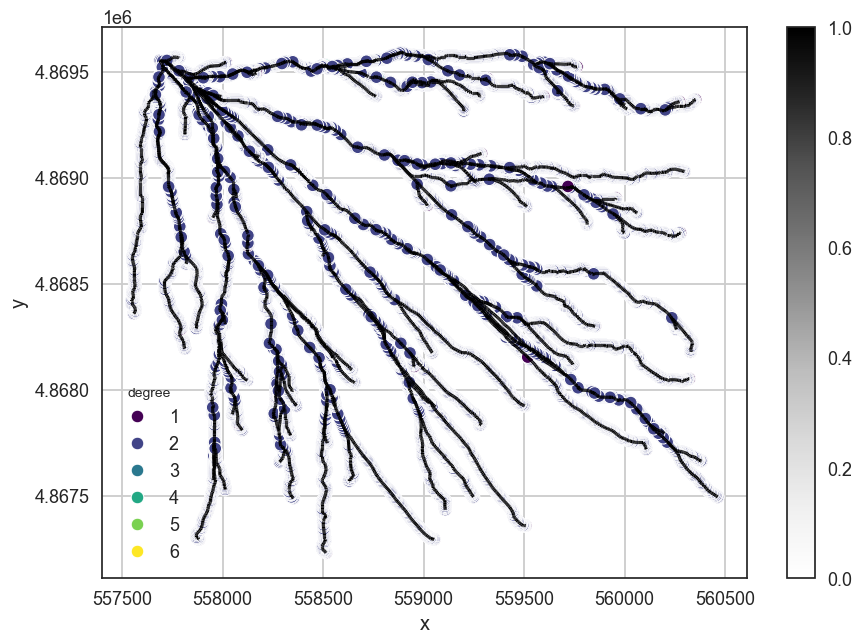

In [29]:
plot_2D_network(nodes, edges, node_color = degree['degree'])

In [47]:
degree = pd.DataFrame(network.graph.degree(), columns = ['id', 'degree'])